# Joint Bayesian Operator Inference: Compressible Euler

## Setup

In [17]:
import sys
sys.path.insert(0, '../..')

import numpy as np
import jax
import jax.numpy as jnp
import opinf
import matplotlib.pyplot as plt
import numpyro
import numpyro.distributions as dist
from numpyro.infer import autoguide

from core import (
    generate_trajectory,
    JaxCompatibleModel,
    grid_search_prior_operator,
    compute_gp_derivatives,
    compute_derivatives_fourth_order,
    generate_rom_predictions,
    plot_deterministic_rom_solves,
    save_paper_figure,
    Plotter,
    DataScaler,
    build_joint_bayesian_model,
    run_joint_svi,
    extract_gp_posterior,
    extract_derivative_posterior,
    gp_based_opinf_baseline,
    rbf_eval,
)
import config
from config import Basis
from euler_plotter import EulerPlotter

numpyro.set_platform('cpu')
numpyro.set_host_device_count(4)

np.random.seed(42)
rng_key = jax.random.PRNGKey(42)

In [18]:
# === EXPERIMENT CONFIGURATION ===
OPERATORS = "cAH"
IVP_METHOD = "RK45"
NUM_MODES = 6

# Data generation
TRAINING_SPAN = (0, 0.08)
PREDICTION_SPAN = (0, config.time_domain[-1])
NUM_SAMPLES = 250
NOISE_LEVEL = 0.03
NUM_EVAL_POINTS = 400  # Set to None for no densification

# Data scaling
USE_SCALED_DATA = False

# Inference settings
GUIDE = autoguide.AutoNormal
VERBOSE = True

# Hyperparameters
GAMMA = 1e4      # Weakly informative — let the ODE constraint identify O
GAMMA2 = 1e1     # ODE constraint slack

# GP hyperparameter priors (LogNormal)
# Tighter priors to prevent the 'null basin' — joint optimisation can
# over-smooth the GP (long ℓ, high ν) and collapse the operator to zero.
# Anchoring noise at the known measurement level and tightening the
# lengthscale scale closes that escape hatch.
GP_LENGTHSCALE_PRIOR_LOC = None          # defaults to log(T/20)
GP_LENGTHSCALE_PRIOR_SCALE = 0.5         # was 1.0 — tighter to prevent over-smoothing
GP_VARIANCE_PRIOR_LOC = None             # defaults to log(var(data))
GP_VARIANCE_PRIOR_SCALE = 0.5
GP_NOISE_PRIOR_LOC = np.log(NOISE_LEVEL) # anchor at known noise level (was -8.0)
GP_NOISE_PRIOR_SCALE = 0.5               # was 1.0 — tighter to prevent signal absorption

# ODE constraint slack (γ₂) — hierarchical prior
LEARN_GAMMA2 = True           # If True, γ₂ is learned per mode; if False, fixed at GAMMA2
GAMMA2_PRIOR_LOC = None       # LogNormal loc for γ₂ prior; None defaults to log(GAMMA2)
GAMMA2_PRIOR_SCALE = 1.0      # LogNormal scale — larger = more freedom to find tightness

# SVI settings
NUM_SVI_STEPS = 50000
LEARNING_RATE = 1e-4
NUM_POSTERIOR_SAMPLES = 1000

# Plotting
NUM_REGRESSION_POINTS = 150

## 1. Generate Training Data

In [19]:
(fom, time_domain_full, true_states, time_sampled, snapshots_sampled) = \
    generate_trajectory(config, config.time_domain, TRAINING_SPAN, NUM_SAMPLES, NOISE_LEVEL)

print(f"Full time domain: {time_domain_full.shape}")
print(f"Sampled times: {time_sampled.shape}")
print(f"Training span: [{TRAINING_SPAN[0]:.4f}, {TRAINING_SPAN[1]:.4f}]")
print(f"Prediction span: [{PREDICTION_SPAN[0]:.4f}, {PREDICTION_SPAN[1]:.4f}]")

generating training data...done in 0.96 s.
Full time domain: (401,)
Sampled times: (250,)
Training span: [0.0000, 0.0800]
Prediction span: [0.0000, 0.1500]


In [20]:
basis = Basis(num_vectors=NUM_MODES)
basis.fit(snapshots_sampled)

snapshots_comp_sampled = basis.compress(snapshots_sampled)
print(f"Compressed shape: {snapshots_comp_sampled.shape}")
print(f"Cumulative energy: {basis.cumulative_energy:.4%}")

# Evaluation time domains
time_domain_eval_training = np.linspace(TRAINING_SPAN[0], TRAINING_SPAN[1], NUM_REGRESSION_POINTS)
time_domain_eval_prediction = np.linspace(PREDICTION_SPAN[0], PREDICTION_SPAN[1], NUM_REGRESSION_POINTS)
full_states_compressed = basis.compress(true_states)

Compressed shape: (6, 250)
Cumulative energy: 88.2756%


In [21]:
if USE_SCALED_DATA:
    data_scaler = DataScaler(num_modes=NUM_MODES)
    data_scaler.fit(snapshots_comp_sampled)
    training_data = data_scaler.transform(snapshots_comp_sampled)
    print(f"Scaling enabled: {data_scaler}")
else:
    data_scaler = None
    training_data = snapshots_comp_sampled
    print("Scaling disabled: using raw POD coefficients")

Scaling disabled: using raw POD coefficients


## 2. Build ROM Structure (for data matrix assembly)

In [22]:
# We need a ROM object for data matrix assembly (operator structure)
# Use a dummy fit with regularization just to set up the model
rom = opinf.ROM(
    basis=basis,
    ddt_estimator=opinf.ddt.NonuniformFiniteDifferencer(time_sampled),
    model=JaxCompatibleModel(operators=OPERATORS, solver=opinf.lstsq.L2Solver(regularizer=1e0))
)
rom.fit(states=snapshots_sampled)
print(f"Operator shape: {rom.model.operator_matrix.shape}")

Operator shape: (6, 28)


## 3. Joint Bayesian Inference

In [23]:
import time
start_time = time.time()

# Build the joint Bayesian model
joint_model, time_eval = build_joint_bayesian_model(
    rom=rom,
    num_modes=NUM_MODES,
    time_domain_sampled=time_sampled,
    snapshots=training_data,
    inputs_eval=None,
    data_scaler=data_scaler if USE_SCALED_DATA else None,
    gp_lengthscale_prior_loc=GP_LENGTHSCALE_PRIOR_LOC,
    gp_lengthscale_prior_scale=GP_LENGTHSCALE_PRIOR_SCALE,
    gp_variance_prior_loc=GP_VARIANCE_PRIOR_LOC,
    gp_variance_prior_scale=GP_VARIANCE_PRIOR_SCALE,
    gp_noise_prior_loc=GP_NOISE_PRIOR_LOC,
    gp_noise_prior_scale=GP_NOISE_PRIOR_SCALE,
    gamma2_prior_loc=GAMMA2_PRIOR_LOC,
    gamma2_prior_scale=GAMMA2_PRIOR_SCALE,
    learn_gamma2=LEARN_GAMMA2,
    num_eval_points=NUM_EVAL_POINTS,
)
print(f"Joint model built. Eval points: {len(time_eval)}")

Joint model built. Eval points: 400


Running joint SVI (gamma=10000.0, gamma2=10.0, guide=AutoNormal, steps=50000)...


100%|██████████| 50000/50000 [26:01<00:00, 32.02it/s, init loss: 170441.2969, avg. loss [47501-50000]: 1656.2668] 


✅ Joint SVI complete! Final loss: 1350.8170
   Sample keys: ['O', 'X_0', 'X_1', 'X_2', 'X_3', 'X_4', 'X_5', 'X_eval_0', 'X_eval_1', 'X_eval_2', 'X_eval_3', 'X_eval_4', 'X_eval_5', 'X_raw_0', 'X_raw_1', 'X_raw_2', 'X_raw_3', 'X_raw_4', 'X_raw_5', 'gamma2_0', 'gamma2_1', 'gamma2_2', 'gamma2_3', 'gamma2_4', 'gamma2_5', 'lengthscale_0', 'lengthscale_1', 'lengthscale_2', 'lengthscale_3', 'lengthscale_4', 'lengthscale_5', 'mu_z_0', 'mu_z_1', 'mu_z_2', 'mu_z_3', 'mu_z_4', 'mu_z_5', 'noise_0', 'noise_1', 'noise_2', 'noise_3', 'noise_4', 'noise_5', 'obs_0', 'obs_1', 'obs_2', 'obs_3', 'obs_4', 'obs_5', 'ode_constraint_0', 'ode_constraint_1', 'ode_constraint_2', 'ode_constraint_3', 'ode_constraint_4', 'ode_constraint_5', 'variance_0', 'variance_1', 'variance_2', 'variance_3', 'variance_4', 'variance_5']


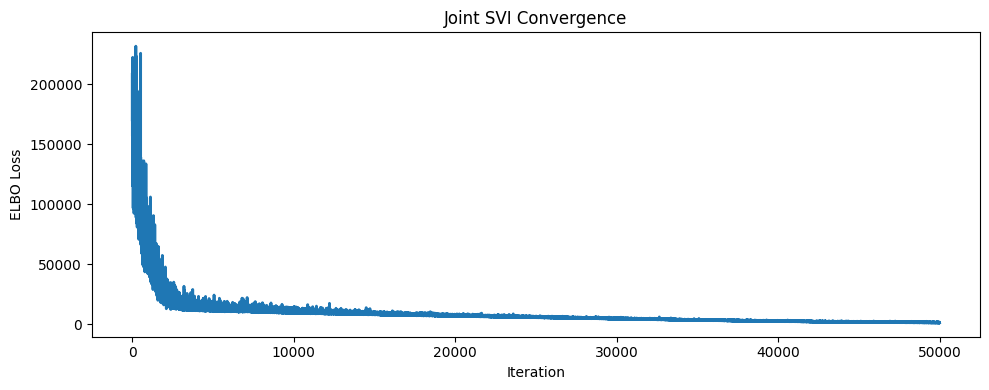

Algorithm runtime: 1566.3s (26.1min)


In [24]:
svi_result = run_joint_svi(
    model=joint_model,
    rng_key=rng_key,
    gamma=GAMMA,
    gamma2=GAMMA2,
    num_steps=NUM_SVI_STEPS,
    learning_rate=LEARNING_RATE,
    num_samples=NUM_POSTERIOR_SAMPLES,
    verbose=VERBOSE,
    guide_class=GUIDE,
    jitter=1e-5
)

# Plot ELBO convergence
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(svi_result.losses, lw=2)
ax.set_xlabel('Iteration')
ax.set_ylabel('ELBO Loss')
ax.set_title('Joint SVI Convergence')
plt.tight_layout()
plt.show()

algo_time = time.time() - start_time
print(f"Algorithm runtime: {algo_time:.1f}s ({algo_time/60:.1f}min)")

In [25]:
samples = svi_result.samples

# Print inferred GP hyperparameters
print("Inferred GP Hyperparameters (median):")
for i in range(NUM_MODES):
    L_i = np.median(samples[f'lengthscale_{i}'])
    V_i = np.median(samples[f'variance_{i}'])
    N_i = np.median(samples[f'noise_{i}'])
    print(f"  Mode {i}: L={L_i:.4f}, V={V_i:.4f}, N={N_i:.6f}")

if LEARN_GAMMA2:
    print("\nInferred ODE constraint slack γ₂ (median):")
    for i in range(NUM_MODES):
        g2_i = np.median(samples[f'gamma2_{i}'])
        print(f"  Mode {i}: γ₂={g2_i:.4f}")


Inferred GP Hyperparameters (median):
  Mode 0: L=0.5332, V=0.4341, N=0.247137
  Mode 1: L=0.4124, V=1.4348, N=0.141659
  Mode 2: L=0.2955, V=3.3595, N=0.066967
  Mode 3: L=0.8512, V=0.9491, N=0.074701
  Mode 4: L=0.2310, V=0.0701, N=0.047637
  Mode 5: L=2.2290, V=0.1277, N=0.040129

Inferred ODE constraint slack γ₂ (median):
  Mode 0: γ₂=0.0519
  Mode 1: γ₂=0.0086
  Mode 2: γ₂=0.0088
  Mode 3: γ₂=0.0085
  Mode 4: γ₂=0.1047
  Mode 5: γ₂=0.0266


## 4. Diagnostic Plots

### Plot 1: GP Fit

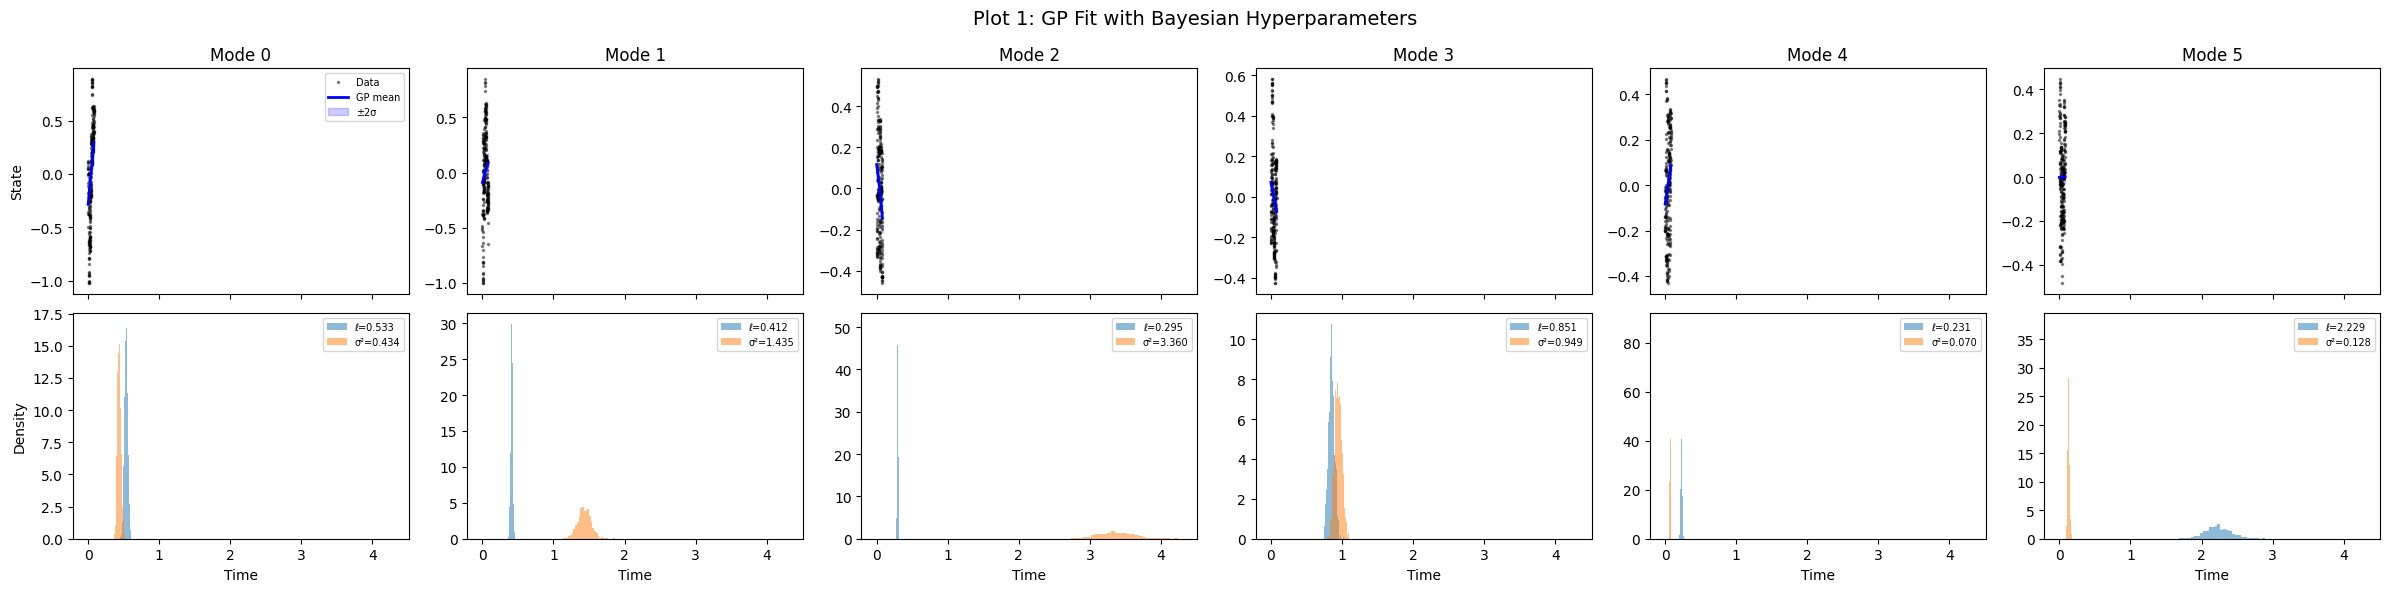

In [26]:
gp_means, gp_stds, Ls, Vs, Ns = extract_gp_posterior(
    samples, NUM_MODES, time_sampled, time_domain_eval_training, training_data,
)

fig, axes = plt.subplots(2, NUM_MODES, figsize=(4 * NUM_MODES, 6), sharex=True)
if NUM_MODES == 1:
    axes = axes[:, np.newaxis]

for i in range(NUM_MODES):
    ax = axes[0, i]
    ax.plot(time_sampled, training_data[i], 'k.', ms=3, alpha=0.4, label='Data')
    ax.plot(time_domain_eval_training, gp_means[i], 'b-', lw=2, label='GP mean')
    ax.fill_between(
        time_domain_eval_training,
        gp_means[i] - 2 * gp_stds[i],
        gp_means[i] + 2 * gp_stds[i],
        alpha=0.2, color='blue', label='\u00b12\u03c3',
    )
    ax.set_title(f'Mode {i}')
    if i == 0:
        ax.set_ylabel('State')
        ax.legend(fontsize=7)

    # GP hyperparameter posterior distributions
    ax2 = axes[1, i]
    ax2.hist(np.array(samples[f'lengthscale_{i}']), bins=30, alpha=0.5, label=f'\u2113={Ls[i]:.3f}', density=True)
    ax2.hist(np.array(samples[f'variance_{i}']), bins=30, alpha=0.5, label=f'\u03c3\u00b2={Vs[i]:.3f}', density=True)
    ax2.legend(fontsize=7)
    if i == 0:
        ax2.set_ylabel('Density')
    ax2.set_xlabel('Time')

fig.suptitle('Plot 1: GP Fit with Bayesian Hyperparameters', fontsize=14)
plt.tight_layout()
plt.show()

### Plot 2: Derivative GP Fit

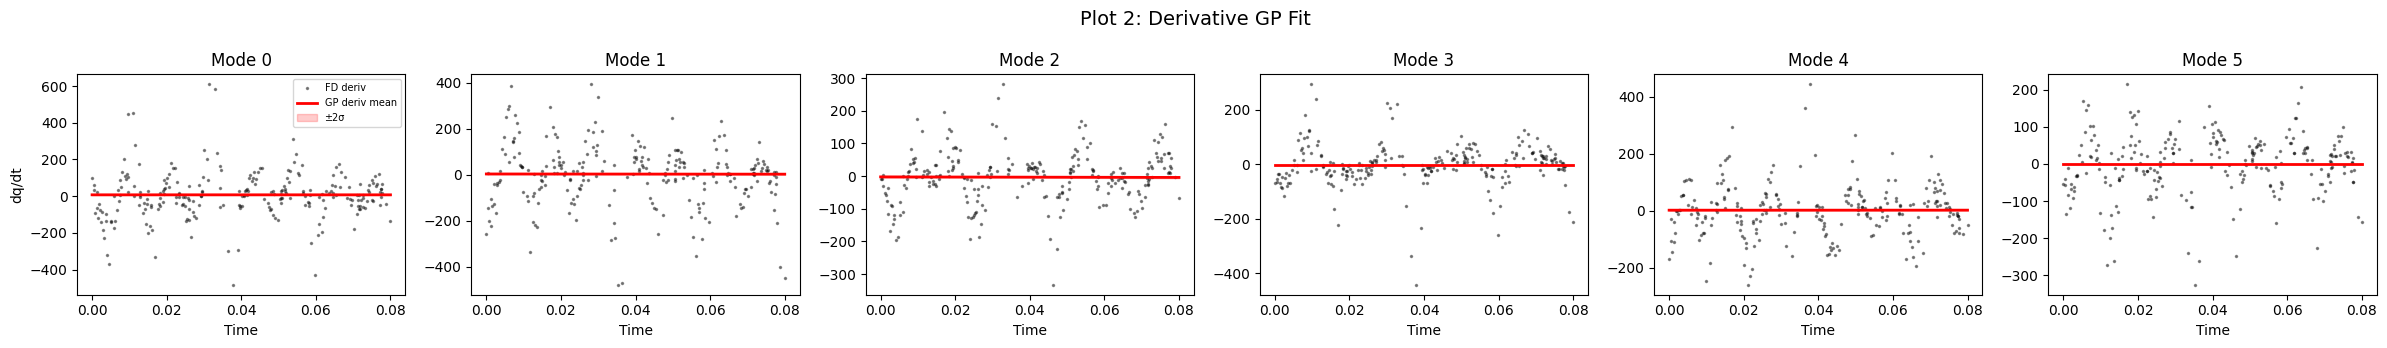

In [27]:
mu_z, std_z = extract_derivative_posterior(
    Ls, Vs, Ns, time_sampled, time_domain_eval_training, training_data,
)

# Finite difference derivatives for comparison
fd_derivs = compute_derivatives_fourth_order(training_data, time_sampled)

fig, axes = plt.subplots(1, NUM_MODES, figsize=(4 * NUM_MODES, 3.5), sharex=True)
if NUM_MODES == 1:
    axes = [axes]

for i in range(NUM_MODES):
    ax = axes[i]
    ax.plot(time_sampled, fd_derivs[i], 'k.', ms=3, alpha=0.4, label='FD deriv')
    ax.plot(time_domain_eval_training, mu_z[i], 'r-', lw=2, label='GP deriv mean')
    ax.fill_between(
        time_domain_eval_training,
        mu_z[i] - 2 * std_z[i],
        mu_z[i] + 2 * std_z[i],
        alpha=0.2, color='red', label='\u00b12\u03c3',
    )
    ax.set_title(f'Mode {i}')
    if i == 0:
        ax.set_ylabel('dq/dt')
        ax.legend(fontsize=7)
    ax.set_xlabel('Time')

fig.suptitle('Plot 2: Derivative GP Fit', fontsize=14)
plt.tight_layout()
plt.show()

### Plot 3: GP-based OpInf Integration (Baseline)

Grid search: testing 41 regularization values...
  reg=1.0e-16: UNSTABLE
  reg=3.2e-16: UNSTABLE
  reg=1.0e-15: UNSTABLE
  reg=3.2e-15: UNSTABLE
  reg=1.0e-14: UNSTABLE
  reg=3.2e-14: UNSTABLE
  reg=1.0e-13: UNSTABLE
  reg=3.2e-13: UNSTABLE
  reg=1.0e-12: UNSTABLE
  reg=3.2e-12: UNSTABLE
  reg=1.0e-11: UNSTABLE
  reg=3.2e-11: UNSTABLE
  reg=1.0e-10: UNSTABLE
  reg=3.2e-10: UNSTABLE
  reg=1.0e-09: UNSTABLE
  reg=3.2e-09: UNSTABLE
  reg=1.0e-08: UNSTABLE
  reg=3.2e-08: UNSTABLE
  reg=1.0e-07: UNSTABLE
  reg=3.2e-07: UNSTABLE
  reg=1.0e-06: UNSTABLE
  reg=3.2e-06: UNSTABLE
  reg=1.0e-05: UNSTABLE
  reg=3.2e-05: STABLE, error=1.827246
  reg=1.0e-04: STABLE, error=3.476141
  reg=3.2e-04: STABLE, error=2.691137
  reg=1.0e-03: STABLE, error=0.010217
  reg=3.2e-03: STABLE, error=0.084423
  reg=1.0e-02: STABLE, error=0.111484
  reg=3.2e-02: STABLE, error=0.103293
  reg=1.0e-01: STABLE, error=0.098366
  reg=3.2e-01: STABLE, error=0.096348
  reg=1.0e+00: STABLE, error=0.092700
  reg=3.2e+00: STAB

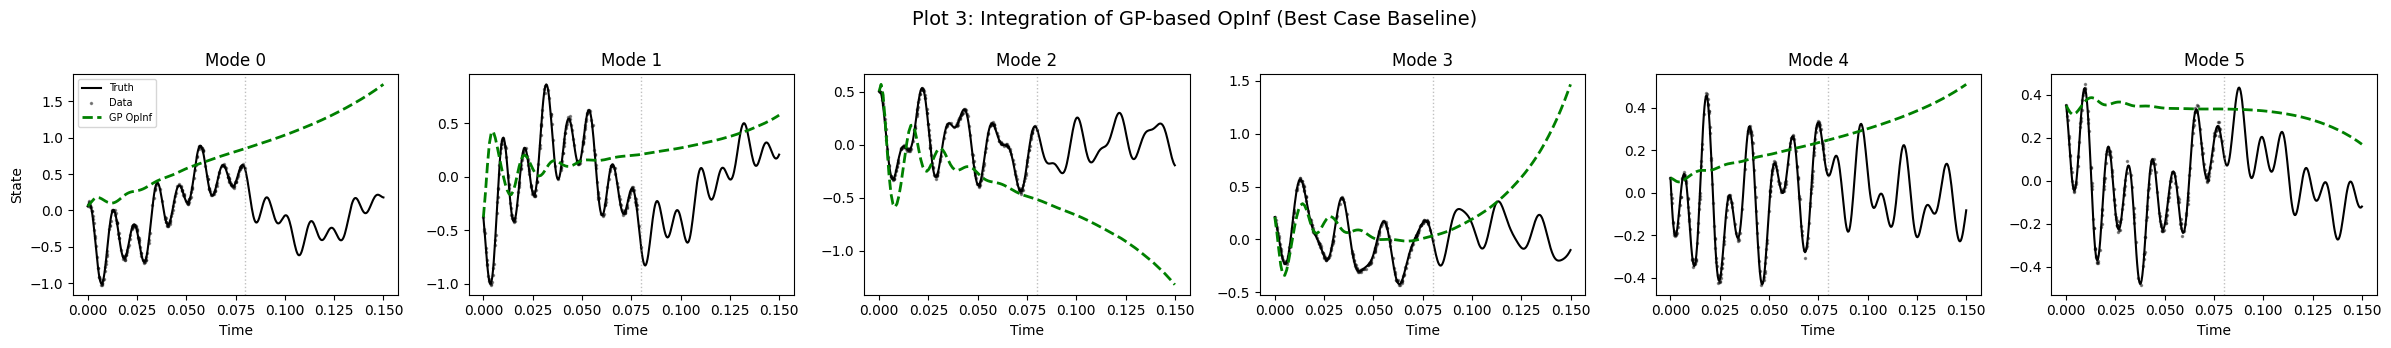

In [28]:
# Fit a deterministic OpInf operator using GP posterior means
gp_means_train, _, _, _, _ = extract_gp_posterior(
    samples, NUM_MODES, time_sampled, time_sampled, training_data,
)

gp_baseline_result = gp_based_opinf_baseline(
    basis=basis,
    gp_means=gp_means_train,
    time_eval=time_sampled,
    snapshots_compressed=snapshots_comp_sampled,
    operators=OPERATORS,
    inputs=None,
    input_func=None,
    ivp_method=IVP_METHOD,
)
print(f"GP baseline reg: {gp_baseline_result.best_reg:.2e}, error: {gp_baseline_result.best_error:.4%}")

# Integrate with the baseline operator
gp_baseline_rom = gp_baseline_result.rom
gp_baseline_rom.model._extract_operators(np.array(gp_baseline_result.operator))
try:
    gp_pred = gp_baseline_rom.model.predict(
        state0=snapshots_comp_sampled[:, 0],
        t=time_domain_eval_prediction,
    )
    gp_pred_sol = gp_baseline_rom.model.predict_result_
    gp_baseline_stable = gp_pred_sol.y.shape[1] >= len(time_domain_eval_prediction)
except Exception:
    gp_baseline_stable = False

fig, axes = plt.subplots(1, NUM_MODES, figsize=(4 * NUM_MODES, 3.5), sharex=True)
if NUM_MODES == 1:
    axes = [axes]

for i in range(NUM_MODES):
    ax = axes[i]
    ax.plot(time_domain_full, full_states_compressed[i], 'k-', lw=1.5, label='Truth')
    ax.plot(time_sampled, snapshots_comp_sampled[i], 'k.', ms=3, alpha=0.4, label='Data')
    if gp_baseline_stable:
        ax.plot(time_domain_eval_prediction, gp_pred_sol.y[i], 'g--', lw=2, label='GP OpInf')
    ax.axvline(TRAINING_SPAN[1], color='gray', ls=':', lw=1, alpha=0.5)
    ax.set_title(f'Mode {i}')
    if i == 0:
        ax.set_ylabel('State')
        ax.legend(fontsize=7)
    ax.set_xlabel('Time')

fig.suptitle('Plot 3: Integration of GP-based OpInf (Best Case Baseline)', fontsize=14)
plt.tight_layout()
plt.show()

### Plot 4: Latent State Fit

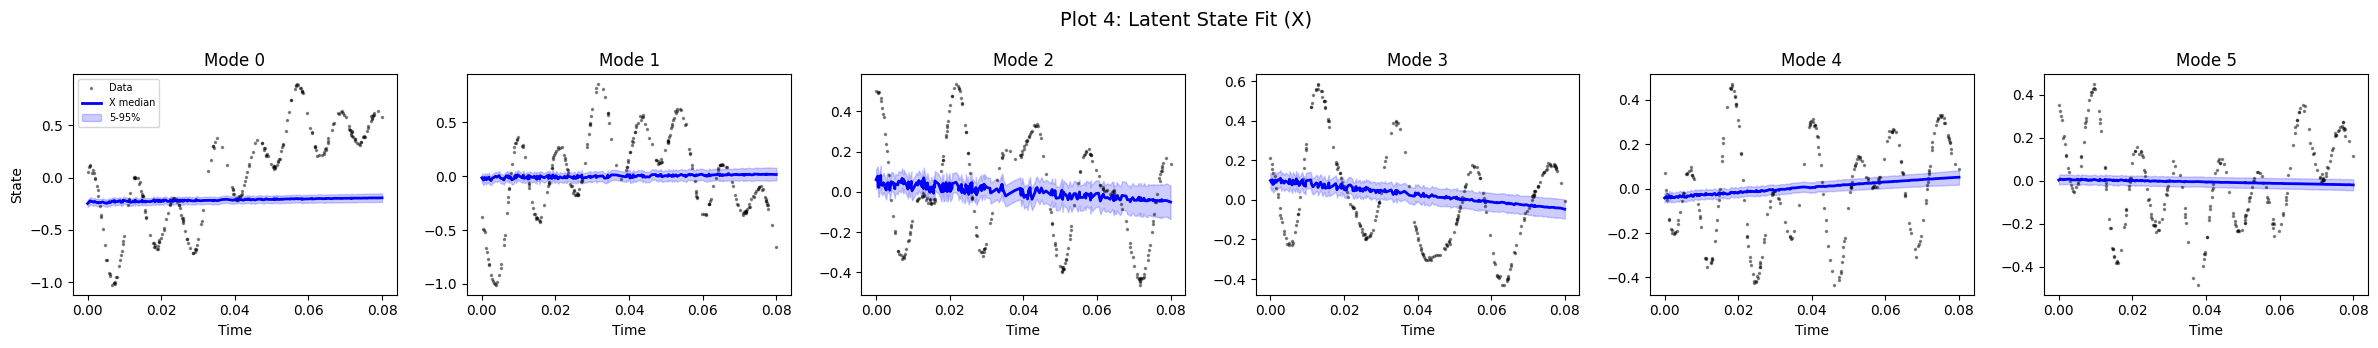

In [29]:
fig, axes = plt.subplots(1, NUM_MODES, figsize=(4 * NUM_MODES, 3.5), sharex=True)
if NUM_MODES == 1:
    axes = [axes]

for i in range(NUM_MODES):
    ax = axes[i]
    X_i = np.array(samples[f'X_{i}'])
    X_median = np.median(X_i, axis=0)
    X_q05 = np.percentile(X_i, 5, axis=0)
    X_q95 = np.percentile(X_i, 95, axis=0)

    ax.plot(time_sampled, training_data[i], 'k.', ms=3, alpha=0.4, label='Data')
    ax.plot(time_sampled, X_median, 'b-', lw=2, label='X median')
    ax.fill_between(time_sampled, X_q05, X_q95, alpha=0.2, color='blue', label='5-95%')
    ax.set_title(f'Mode {i}')
    if i == 0:
        ax.set_ylabel('State')
        ax.legend(fontsize=7)
    ax.set_xlabel('Time')

fig.suptitle('Plot 4: Latent State Fit (X)', fontsize=14)
plt.tight_layout()
plt.show()

### Plot 5: Derivative Operator Fit

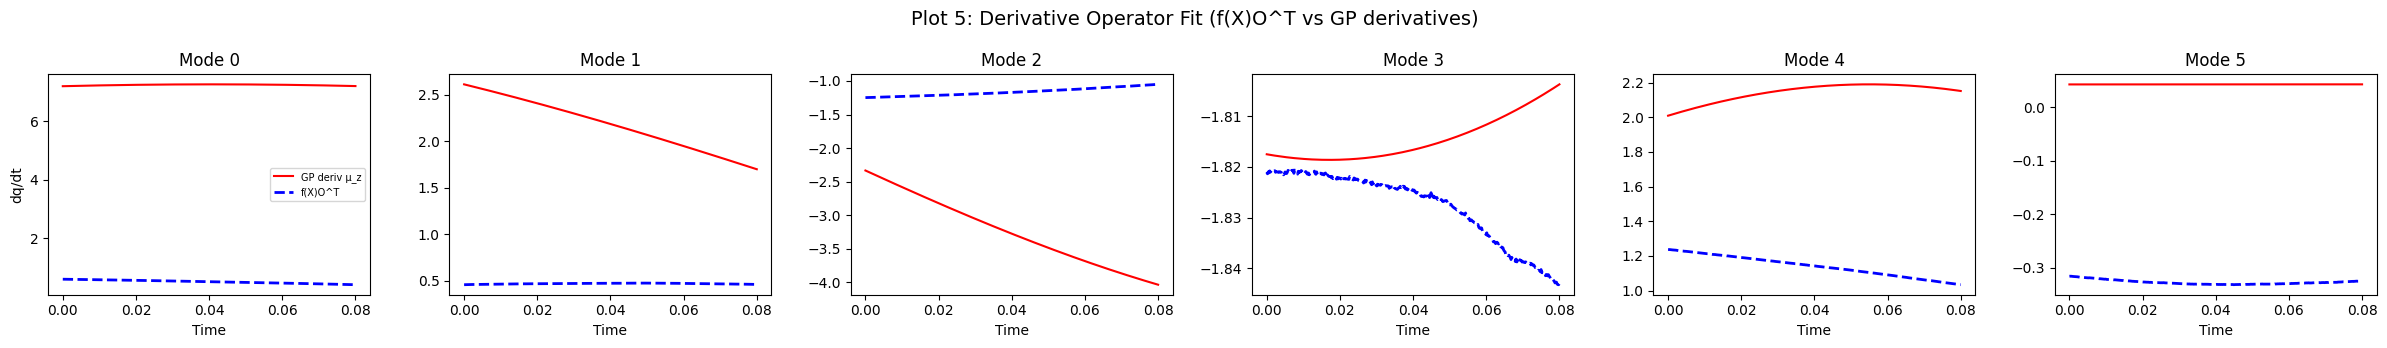

In [30]:
from core.bayesian_opinf import _find_operator_samples

O_samples = _find_operator_samples(samples, "O")
if O_samples.ndim == 2:
    O_samples = O_samples[np.newaxis, ...]

# Use median operator and median latent states at eval points
O_median = np.median(O_samples, axis=0)

# Get latent states at eval points
if f'X_eval_0' in samples:
    Xs_eval_median = np.array([np.median(samples[f'X_eval_{i}'], axis=0) for i in range(NUM_MODES)])
else:
    Xs_eval_median = np.array([np.median(samples[f'X_{i}'], axis=0) for i in range(NUM_MODES)])

if USE_SCALED_DATA and data_scaler is not None:
    Xs_eval_orig = np.array([
        Xs_eval_median[i] * data_scaler.stds_[i, 0] + data_scaler.means_[i, 0]
        for i in range(NUM_MODES)
    ])
else:
    Xs_eval_orig = Xs_eval_median

# Compute f(X) @ O^T
f_X = np.array(rom.model._assemble_data_matrix(jnp.array(Xs_eval_orig), inputs=None) @ jnp.array(O_median).T)
if USE_SCALED_DATA and data_scaler is not None:
    f_X_scaled = np.array([f_X.T[i] / data_scaler.stds_[i, 0] for i in range(NUM_MODES)])
else:
    f_X_scaled = f_X.T

# Use the time_eval from model building
t_eval_plot = time_eval if f'X_eval_0' in samples else time_sampled

fig, axes = plt.subplots(1, NUM_MODES, figsize=(4 * NUM_MODES, 3.5), sharex=True)
if NUM_MODES == 1:
    axes = [axes]

for i in range(NUM_MODES):
    ax = axes[i]
    ax.plot(time_domain_eval_training, mu_z[i], 'r-', lw=1.5, label='GP deriv \u03bc_z')
    ax.plot(t_eval_plot, f_X_scaled[i], 'b--', lw=2, label='f(X)O^T')
    ax.set_title(f'Mode {i}')
    if i == 0:
        ax.set_ylabel('dq/dt')
        ax.legend(fontsize=7)
    ax.set_xlabel('Time')

fig.suptitle('Plot 5: Derivative Operator Fit (f(X)O^T vs GP derivatives)', fontsize=14)
plt.tight_layout()
plt.show()

### Plot 6: Integrated Operator Fit (ROM Predictions)

Operator samples: 200, Stable solves: 200


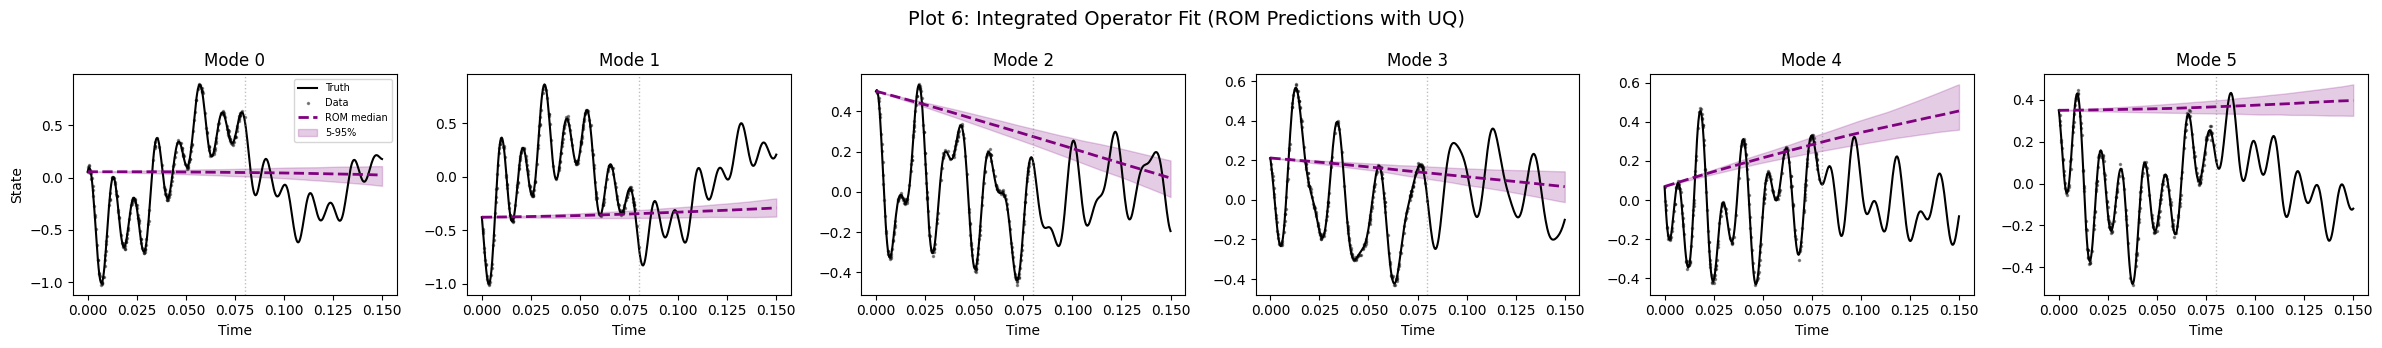

In [31]:
Os, Xs, rom_solves = generate_rom_predictions(
    samples=samples, rom=rom,
    snapshots_compressed=snapshots_comp_sampled,
    time_eval=time_domain_eval_prediction,
    num_modes=NUM_MODES, num_pulls=200,
    input_func=None,
    data_scaler=data_scaler if USE_SCALED_DATA else None,
    ivp_method=IVP_METHOD,
)
print(f"Operator samples: {len(Os)}, Stable solves: {len(rom_solves)}")

fig, axes = plt.subplots(1, NUM_MODES, figsize=(4 * NUM_MODES, 3.5), sharex=True)
if NUM_MODES == 1:
    axes = [axes]

for i in range(NUM_MODES):
    ax = axes[i]
    ax.plot(time_domain_full, full_states_compressed[i], 'k-', lw=1.5, label='Truth')
    ax.plot(time_sampled, snapshots_comp_sampled[i], 'k.', ms=3, alpha=0.4, label='Data')

    if len(rom_solves) > 0:
        rom_arr = np.array(rom_solves)
        median = np.median(rom_arr[:, i, :], axis=0)
        q05 = np.percentile(rom_arr[:, i, :], 5, axis=0)
        q95 = np.percentile(rom_arr[:, i, :], 95, axis=0)
        ax.plot(time_domain_eval_prediction, median, 'purple', ls='--', lw=2, label='ROM median')
        ax.fill_between(time_domain_eval_prediction, q05, q95, alpha=0.2, color='purple', label='5-95%')

    ax.axvline(TRAINING_SPAN[1], color='gray', ls=':', lw=1, alpha=0.5)
    ax.set_title(f'Mode {i}')
    if i == 0:
        ax.set_ylabel('State')
        ax.legend(fontsize=7)
    ax.set_xlabel('Time')

fig.suptitle('Plot 6: Integrated Operator Fit (ROM Predictions with UQ)', fontsize=14)
plt.tight_layout()
plt.show()

## 5. Summary

In [32]:
print("=" * 60)
print("EXPERIMENT SUMMARY: Compressible Euler (Joint Bayesian)")
print("=" * 60)
print(f"Operators: {OPERATORS}")
print(f"Modes: {NUM_MODES}")
print(f"Training span: [{TRAINING_SPAN[0]}, {TRAINING_SPAN[1]}]")
print(f"Prediction span: [{PREDICTION_SPAN[0]}, {PREDICTION_SPAN[1]}]")
print(f"Scaling: {'enabled' if USE_SCALED_DATA else 'disabled'}")
print(f"Gamma (operator): {GAMMA}")
print(f"Gamma2 (ODE): {GAMMA2}")
print(f"Guide: {GUIDE.__name__}")
print(f"SVI steps: {NUM_SVI_STEPS}")
print(f"Learning rate: {LEARNING_RATE}")
print(f"\nInferred GP Hyperparameters:")
for i in range(NUM_MODES):
    print(f"  Mode {i}: L={Ls[i]:.4f}, V={Vs[i]:.4f}, N={Ns[i]:.6f}")
print(f"\nOperator samples: {len(Os)}")
print(f"Stable ROM solves: {len(rom_solves)}")
print(f"Algorithm runtime: {algo_time:.1f}s ({algo_time/60:.1f}min)")

EXPERIMENT SUMMARY: Compressible Euler (Joint Bayesian)
Operators: cAH
Modes: 6
Training span: [0, 0.08]
Prediction span: [0, 0.15]
Scaling: disabled
Gamma (operator): 10000.0
Gamma2 (ODE): 10.0
Guide: AutoNormal
SVI steps: 50000
Learning rate: 0.0001

Inferred GP Hyperparameters:
  Mode 0: L=0.5332, V=0.4341, N=0.247137
  Mode 1: L=0.4124, V=1.4348, N=0.141659
  Mode 2: L=0.2955, V=3.3595, N=0.066967
  Mode 3: L=0.8512, V=0.9491, N=0.074701
  Mode 4: L=0.2310, V=0.0701, N=0.047637
  Mode 5: L=2.2290, V=0.1277, N=0.040129

Operator samples: 200
Stable ROM solves: 200
Algorithm runtime: 1566.3s (26.1min)
